In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')

# Separating features and target variables
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

print(f"\n Dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Class imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")


 Dataset shape: (41188, 20)
Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64
Class imbalance ratio: 7.88:1


In [3]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

print(f"\n Categorical columns ({len(categorical_cols)}):")
print(categorical_cols.tolist())

print(f"\n Numerical columns ({len(numeric_cols)}):")
print(numeric_cols.tolist())




 Categorical columns (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

 Numerical columns (10):
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [4]:

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols), #one hot encoding for categorical
        ('num', StandardScaler(), numeric_cols)  # StandardScaler is crucial for SVM
    ]
)

print("preprocessor made, with onehot encoder for categorical features and standard scalar for numeric ones.")



preprocessor made, with onehot encoder for categorical features and standard scalar for numeric ones.


In [5]:

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=1))  # SVC with random_state for reproducibility
])



In [6]:

param_grid = {
    'model__C': [0.1, 1, 10],                      # Regularization parameter
    'model__kernel': ['linear', 'rbf'],             # Kernel type
    'model__gamma': ['scale', 'auto'],              # Kernel coefficient (for rbf)
    'model__class_weight': [None, 'balanced']       # Handle class imbalance
}

print("\n Hyperparameter Grid:")
print(f"   C (regularization): {param_grid['model__C']}")
print(f"   kernel: {param_grid['model__kernel']}")
print(f"   gamma: {param_grid['model__gamma']}")
print(f"   class_weight: {param_grid['model__class_weight']}")
print(f"\n   Total combinations: {len(param_grid['model__C']) * len(param_grid['model__kernel']) * len(param_grid['model__gamma']) * len(param_grid['model__class_weight'])}")




 Hyperparameter Grid:
   C (regularization): [0.1, 1, 10]
   kernel: ['linear', 'rbf']
   gamma: ['scale', 'auto']
   class_weight: [None, 'balanced']

   Total combinations: 24


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print(f"\n Data split:")
print(f"   Training set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")




 Data split:
   Training set: (32950, 20)
   Test set: (8238, 20)


In [8]:
# Grid Search with Cross-Validation
print("\n Starting GridSearchCV...")
print("   This will train 5-fold CV for each parameter combination")


grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1'  # Using F1 score due to class imbalance
)

grid_search.fit(X_train, y_train)

print(f"\n Training complete!")
print(f"\n Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param.replace('model__', '')}: {value}")
print(f"\n Best cross-validation F1 score: {grid_search.best_score_:.4f}")




 Starting GridSearchCV...
   This will train 5-fold CV for each parameter combination
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Training complete!

 Best parameters found:
   C: 1
   class_weight: balanced
   gamma: scale
   kernel: rbf

 Best cross-validation F1 score: 0.5811


In [9]:

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Predictions made on test set")




 Predictions made on test set


In [10]:

print("\n" + "="*70)
print("MODEL EVALUATION RESULTS")
print("="*70)

#accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy: {accuracy:.4f}")

#classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

#confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(" Confusion Matrix:")
print(cm)
print("\nBreakdown:")
print(f"   True Negatives (TN):  {cm[0,0]}")
print(f"   False Positives (FP): {cm[0,1]}")
print(f"   False Negatives (FN): {cm[1,0]}")
print(f"   True Positives (TP):  {cm[1,1]}")

#additional Metrics like tn fp tp and more
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n Additional Metrics:")
print(f"   Precision (Positive Predictive Value): {precision:.4f}")
print(f"   Recall (Sensitivity/True Positive Rate): {recall:.4f}")
print(f"   Specificity (True Negative Rate): {specificity:.4f}")




MODEL EVALUATION RESULTS

 Accuracy: 0.8507

 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7310
           1       0.42      0.90      0.58       928

    accuracy                           0.85      8238
   macro avg       0.70      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238

 Confusion Matrix:
[[6169 1141]
 [  89  839]]

Breakdown:
   True Negatives (TN):  6169
   False Positives (FP): 1141
   False Negatives (FN): 89
   True Positives (TP):  839

 Additional Metrics:
   Precision (Positive Predictive Value): 0.4237
   Recall (Sensitivity/True Positive Rate): 0.9041
   Specificity (True Negative Rate): 0.8439



 Saved: SVM_confusion_matrix.png


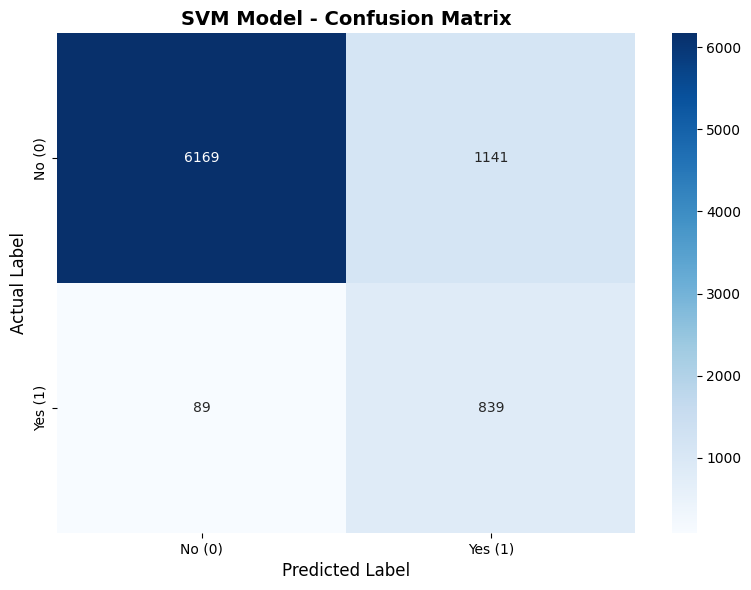

In [11]:

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('SVM Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('output/SVM_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n Saved: SVM_confusion_matrix.png")
plt.show()



In [12]:
print("\n" + "="*70)
print("CROSS-VALIDATION vs TEST SET COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['F1 Score', 'Accuracy'],
    'CV (Training)': [grid_search.best_score_, 'N/A'],
    'Test Set': [f"{2 * precision * recall / (precision + recall):.4f}", f"{accuracy:.4f}"]
})

print("\n", comparison_df.to_string(index=False))
print("\nNote: Similar scores indicate good generalization (no overfitting)")




CROSS-VALIDATION vs TEST SET COMPARISON

   Metric CV (Training) Test Set
F1 Score      0.581122   0.5770
Accuracy           N/A   0.8507

Note: Similar scores indicate good generalization (no overfitting)


In [13]:

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"""
 Best SVM Configuration:
   - Regularization parameter (C): {grid_search.best_params_['model__C']}
   - Kernel type: {grid_search.best_params_['model__kernel']}
   - Gamma: {grid_search.best_params_['model__gamma']}
   - Class weight: {grid_search.best_params_['model__class_weight']}
   
 Model Interpretation:
   - C controls the trade-off between smooth decision boundary and classifying training points correctly
   - {'Linear kernel' if grid_search.best_params_['model__kernel'] == 'linear' else 'RBF kernel'} was selected, indicating {'linear separability' if grid_search.best_params_['model__kernel'] == 'linear' else 'complex, non-linear patterns'}
   - {'Balanced class weights' if grid_search.best_params_['model__class_weight'] == 'balanced' else 'Default class weights'} {'help address the class imbalance' if grid_search.best_params_['model__class_weight'] == 'balanced' else 'were used'}
""")




KEY INSIGHTS

 Best SVM Configuration:
   - Regularization parameter (C): 1
   - Kernel type: rbf
   - Gamma: scale
   - Class weight: balanced
   
 Model Interpretation:
   - C controls the trade-off between smooth decision boundary and classifying training points correctly
   - RBF kernel was selected, indicating complex, non-linear patterns
   - Balanced class weights help address the class imbalance



##SHAP not done for knn and suport vector machine due to difficulties with kernel shap. 